# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [345]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [346]:
# untuk plot Q-Q
import scipy.stats as stats

In [347]:
df_california = pd.read_csv('../data/california_dataset.csv')

In [348]:
from sklearn.model_selection import train_test_split
train_california, test_california = train_test_split(df_california, test_size=0.2, random_state=42)
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

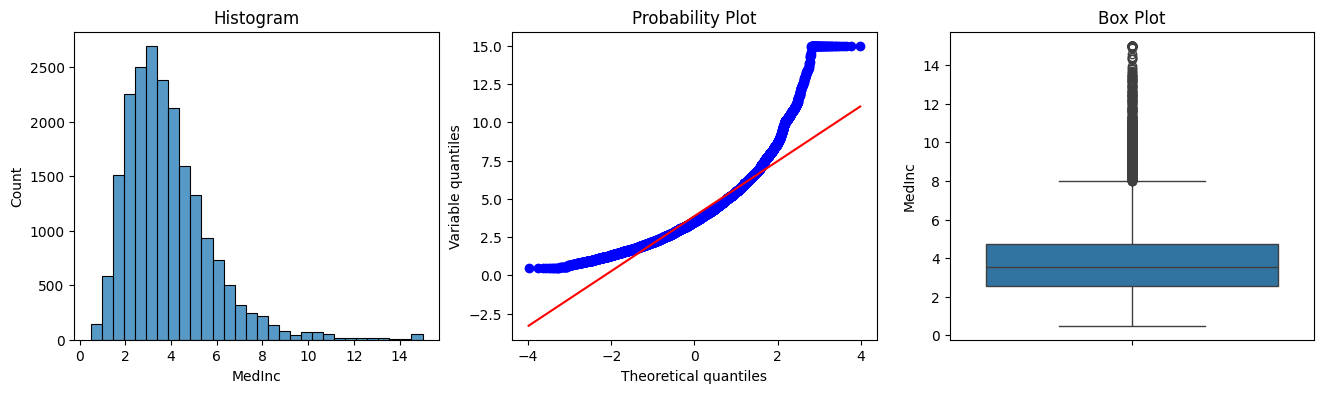

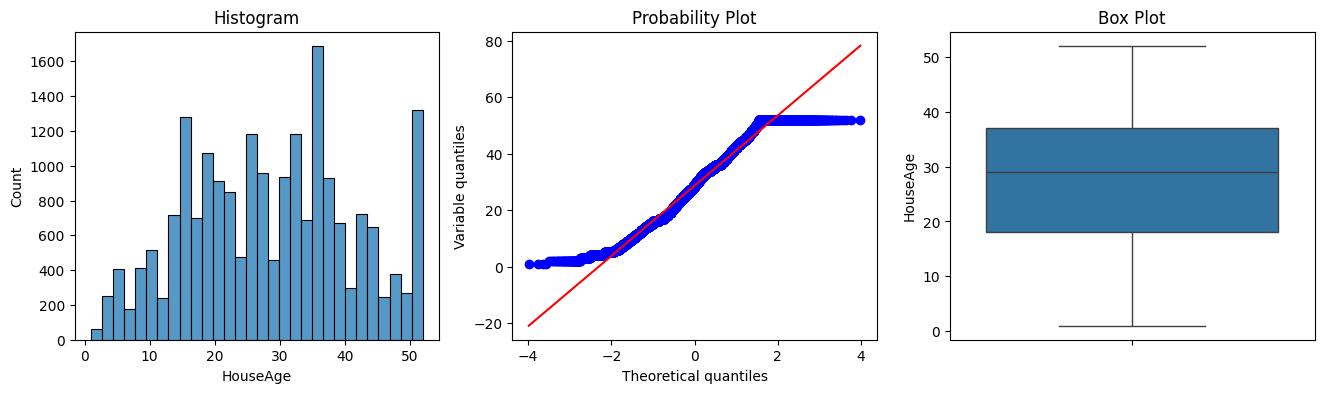

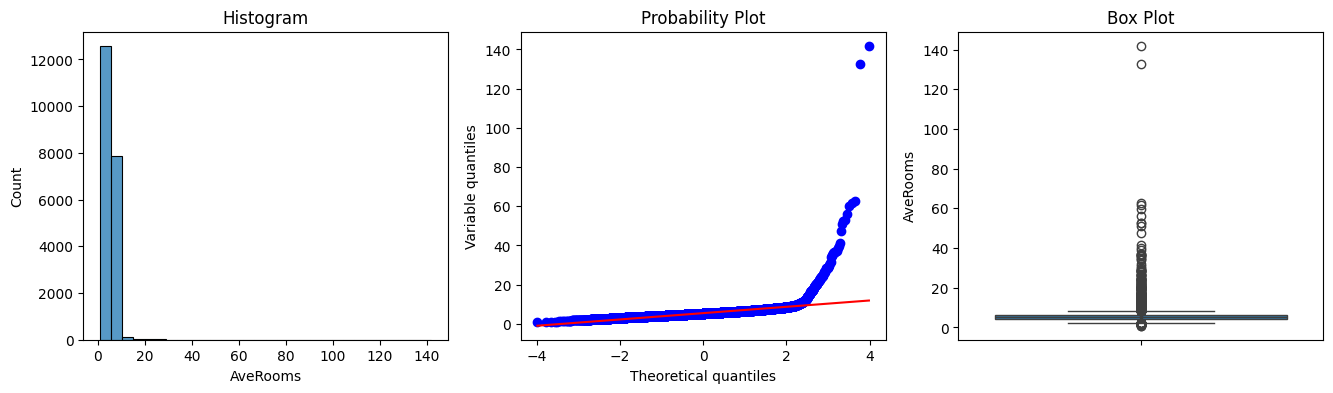

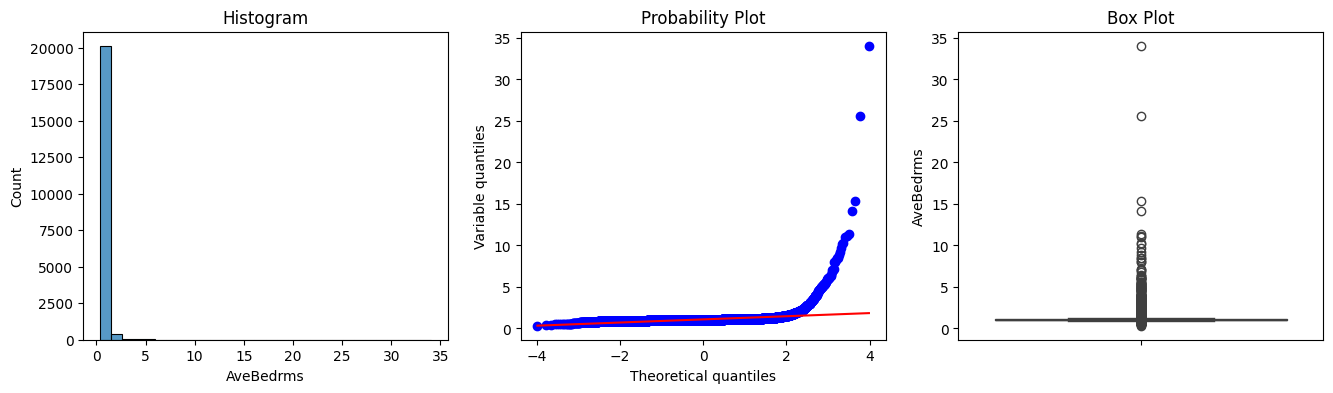

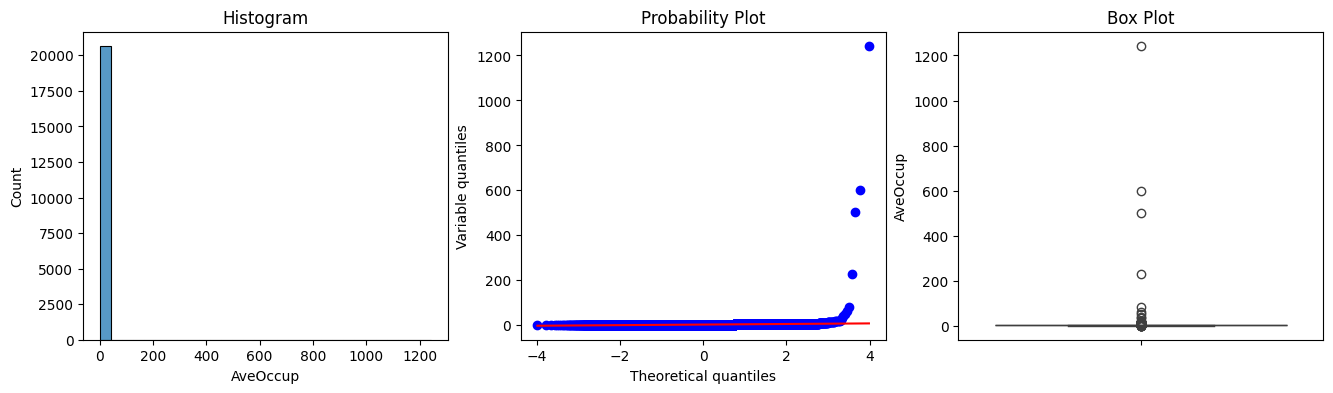

In [349]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
for kolom in kolom_kolom:
    plt.figure(figsize=(16, 4))
    
    
    # plot histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df_california[kolom], bins=30)
    plt.title("Histogram")
    
    # plot Q - Q
    plt.subplot(1, 3, 2)
    stats.probplot(df_california[kolom], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')
    
    # bos plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=(df_california[kolom]))
    plt.title("Box Plot")
    
    plt.show

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [350]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
def find_outlier_boundary(df_california, variabel):
    IQR = df_california[variabel].quantile(0.75) - df_california[variabel].quantile(0.25)
    
    lower_boundary = df_california[variabel].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df_california[variabel].quantile(0.75) + (IQR * 1.5)
    
    return upper_boundary, lower_boundary

AveRooms_upper_limit, AveRooms_lower_limit = find_outlier_boundary(train_california, 'AveRooms')

print("Nilai upper limit AveRooms : ", AveRooms_upper_limit)
print("Nilai lower limit AveRooms : ", AveRooms_lower_limit)


Nilai upper limit AveRooms :  8.474509781463325
Nilai lower limit AveRooms :  2.0385818023548827


In [351]:
train_california['AveRooms'] = np.where(
    train_california['AveRooms'] > AveRooms_upper_limit, AveRooms_upper_limit,
    np.where(
        train_california['AveRooms'] < AveRooms_lower_limit, AveRooms_lower_limit,
        train_california['AveRooms']
    )
)

<function matplotlib.pyplot.show(close=None, block=None)>

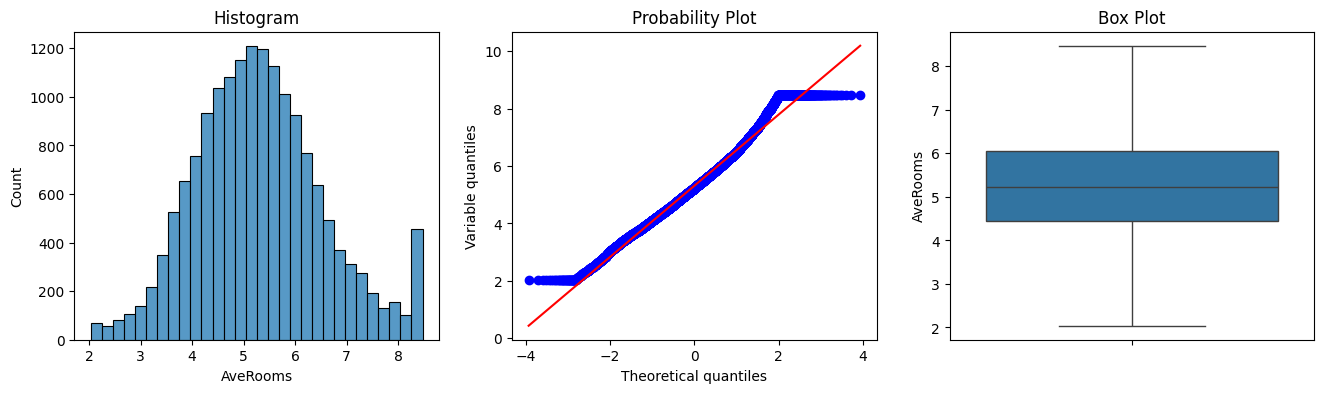

In [352]:
plt.figure(figsize=(16, 4))
    
# plot histogram
plt.subplot(1, 3, 1)
sns.histplot(train_california['AveRooms'], bins=30)
plt.title("Histogram")

# plot Q - Q
plt.subplot(1, 3, 2)
stats.probplot(train_california['AveRooms'], dist="norm", plot=plt)
plt.ylabel('Variable quantiles')

# bos plot
plt.subplot(1, 3, 3)
sns.boxplot(y=(train_california['AveRooms']))
plt.title("Box Plot")

plt.show

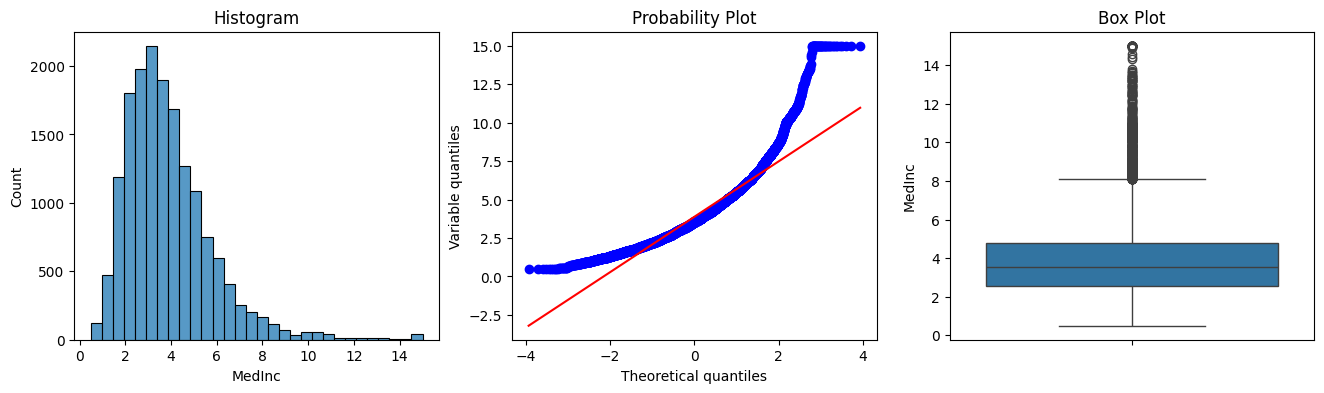

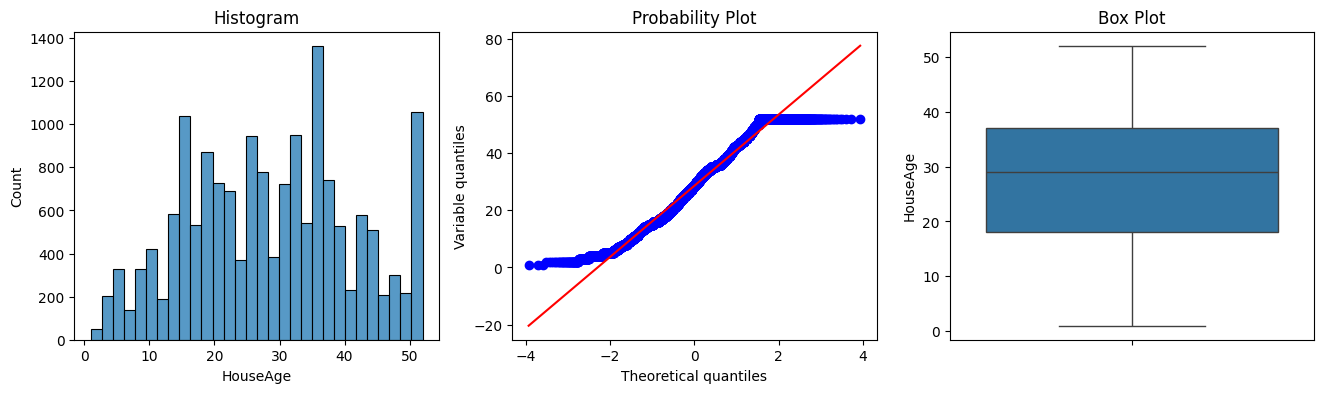

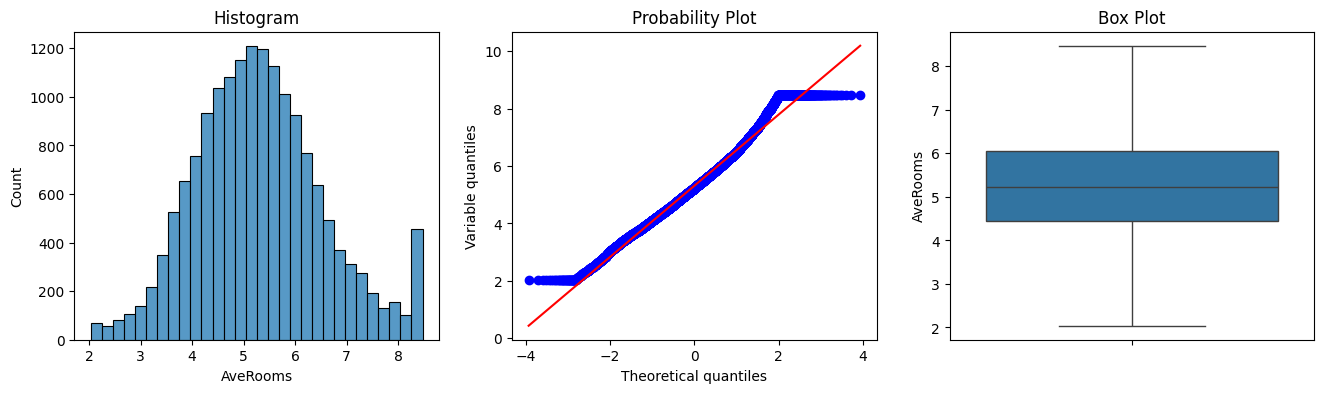

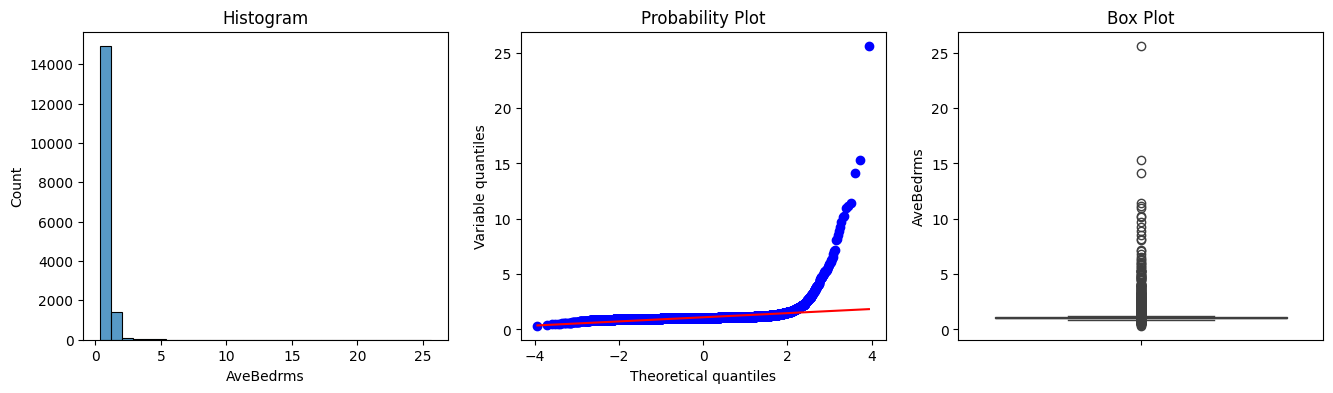

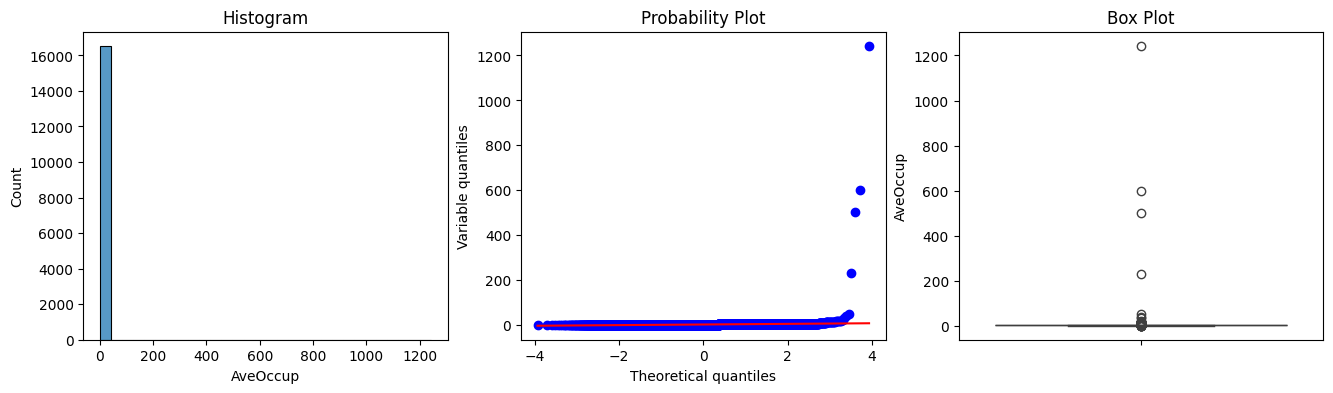

In [353]:
# Melakukan loop untuk mengecek distribusi tiap kolom
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
for kolom in kolom_kolom:
    plt.figure(figsize=(16, 4))
    
    
    # plot histogram
    plt.subplot(1, 3, 1)
    sns.histplot(train_california[kolom], bins=30)
    plt.title("Histogram")
    
    # plot Q - Q
    plt.subplot(1, 3, 2)
    stats.probplot(train_california[kolom], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')
    
    # bos plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=(train_california[kolom]))
    plt.title("Box Plot")
    
    plt.show

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [354]:
df_company = pd.read_csv('../data/company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [355]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size=0.2, random_state=42)
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [356]:
#Tulis jawaban missing value handling kolom Headquarters disini
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [357]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [358]:
missing_count = df_company['Headquarters'].isna().sum()
total_data = len(df_company)

missing_persentase = (missing_count / total_data * 100)

print("Jumlah Missing Value :", missing_count)
print("Total Data :", total_data)
print("Persentase Missing Value :", missing_persentase, "%")

Jumlah Missing Value : 0
Total Data : 672
Persentase Missing Value : 0.0 %


In [359]:
for column in df_company.columns:
    print(f"============ {column} ===========")
    display(df_company[column].value_counts())
    print()
    

============ Revenue ===========


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============ Size ===========


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============ Rating ===========


Rating
 3.5    58
-1.0    50
 4.0    41
 3.3    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 4.3    14
 2.9    14
 4.6    12
 3.1    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============ Headquarters ===========


Headquarters
New York, NY                 33
-1                           31
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, United Kingdom    10
Cambridge, MA                10
Vienna, VA                    8
Denver, CO                    7
Herndon, VA                   7
Washington, DC                7
Woodbine, MD                  7
Saint Louis, MO               7
Bedford, MA                   7
Arlington, VA                 7
San Jose, CA                  7
San Antonio, TX               6
Mountain View, CA             6
Basel, Switzerland            6
San Rafael, CA                6
Chantilly, VA                 6
Fairfax, VA                   5
Houston, TX                   5
Pittsburgh, PA                5
Bethesda, MD                  5
Rockville, MD                 5
Los Angeles, CA               5
Springfield, MA            

In [360]:
100 * len(df_company[df_company['Headquarters'].isin(['-1'])]) / len(df_company)

4.613095238095238

In [361]:
mode_headquarters_train = train_company[train_company['Headquarters']!='-1']['Headquarters'].mode()[0]
train_company['Headquarters'] = train_company['Headquarters'].replace('-1', mode_headquarters_train)

In [362]:
mode_headquarters_train

'New York, NY'

In [363]:
train_company['Rating'] = train_company['Rating'].apply(lambda x: mode_headquarters_train if x==-1 else x)
test_company['Rating'] = test_company['Rating'].apply(lambda x: mode_headquarters_train if x==-1 else x)

In [364]:
train_company['Headquarters'].value_counts()

Headquarters
New York, NY                 53
San Francisco, CA            28
Chicago, IL                  20
Boston, MA                   13
Mc Lean, VA                  12
Westminster, CO              10
Reston, VA                    9
Cambridge, United Kingdom     8
Cambridge, MA                 8
San Jose, CA                  7
Bedford, MA                   7
Vienna, VA                    7
Woodbine, MD                  6
Mountain View, CA             6
Arlington, VA                 6
Herndon, VA                   6
Washington, DC                6
Saint Louis, MO               6
San Antonio, TX               5
Denver, CO                    5
Los Angeles, CA               5
Chantilly, VA                 5
Bethesda, MD                  5
Orlando, FL                   4
Pleasanton, CA                4
Memphis, TN                   4
Raleigh, NC                   4
Princeton, NJ                 4
Santa Cruz, CA                4
Austin, TX                    4
San Rafael, CA             

## Jawaban dari Assignment 2. Missing Value Handling :
1. Pada kolom Headquarters ditemukan nilai "-1" yang merepresentasikan missing value. 
Nilai tersebut kemudian dikonversi menjadi NaN sehingga dapat dihitung sebagai missing value.

2. Persentase missing value sekitar 4.6%. 
Karena persentase missing value kurang dari 20%, maka kolom Headquarters tidak di-drop.

3. Handling missing value dilakukan menggunakan metode modus karena kolom Headquarters merupakan data kategorikal (nama lokasi perusahaan).

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [365]:
df_churn = pd.read_csv('../data/TelcoCustomerChurn.csv')

In [366]:
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split
train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)


In [367]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [368]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# Kolom yang ingin saya encode
column_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

label_encoder = LabelEncoder()

In [369]:
#Cek nilai-nilai di kolom kategorikal
for column in column_to_encode:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


============= StreamingTV =================


StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


============= TechSupport =================


...

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


============= OnlineSecurity =================


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


============= MultipleLines =================


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [370]:
df_churn['StreamingMovies'] = df_churn['StreamingMovies'].replace({'No internet service':'No'})
df_churn['StreamingTV'] = df_churn['StreamingTV'].replace({'No internet service':'No'})
df_churn['TechSupport'] = df_churn['TechSupport'].replace({'No internet service':'No'})
df_churn['DeviceProtection'] = df_churn['DeviceProtection'].replace({'No internet service':'No'})
df_churn['OnlineBackup'] = df_churn['OnlineBackup'].replace({'No internet service':'No'})
df_churn['OnlineSecurity'] = df_churn['OnlineSecurity'].replace({'No internet service':'No'})
df_churn['MultipleLines'] = df_churn['MultipleLines'].replace({'No phone service':'No'})
train_churn['MultipleLines'] = train_churn['MultipleLines'].replace({'No phone service':'No'})
test_churn['MultipleLines'] = test_churn['MultipleLines'].replace({'No phone service':'No'})

cols = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

for col in cols:
    train_churn[col] = train_churn[col].replace({'No internet service':'No'})
    test_churn[col] = test_churn[col].replace({'No internet service':'No'})

In [371]:
#Cek nilai-nilai di kolom kategorikal
for column in column_to_encode:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


============= StreamingTV =================


StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64


============= TechSupport =================


...

OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64


============= OnlineSecurity =================


OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64


============= MultipleLines =================


MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

In [372]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [373]:
for col in column_to_encode:
    train_churn[col] = label_encoder.fit_transform(train_churn[col])

In [374]:
for col in column_to_encode:
    test_churn[col] = label_encoder.fit_transform(test_churn[col])

In [375]:
train_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2142,4223-BKEOR,Female,0,No,Yes,21,Yes,0,DSL,1,0,1,0,0,1,One year,No,Mailed check,64.85,1336.8,No
1623,6035-RIIOM,Female,0,No,No,54,Yes,1,Fiber optic,0,1,0,0,1,1,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
6074,3797-VTIDR,Male,0,Yes,No,1,No,0,DSL,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
1362,2568-BRGYX,Male,0,No,No,4,Yes,0,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,1,DSL,1,1,0,1,0,0,Two year,Yes,Bank transfer (automatic),61.90,,No


In [376]:
test_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,0,DSL,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,1,No,0,0,0,0,0,0,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,0,No,0,0,0,0,0,0,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,0,Fiber optic,0,0,1,0,0,0,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,0,DSL,0,0,0,1,0,0,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## Selesai :)